<a href="https://colab.research.google.com/github/kmyers111/ML-Models/blob/main/supervised/StudentPerformancePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

In [20]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Students Performance .csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "prajwalkanade/student-performance-prediction-dataset",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'student-performance-prediction-dataset' dataset.
First 5 records:   Student_ID Student_Age     Sex High_School_Type Scholarship Additional_Work  \
0   STUDENT1       19-22    Male            Other         50%             Yes   
1   STUDENT2       19-22    Male            Other         50%             Yes   
2   STUDENT3       19-22    Male            State         50%              No   
3   STUDENT4          18  Female          Private         50%             Yes   
4   STUDENT5       19-22    Male          Private         50%              No   

  Sports_activity Transportation  Weekly_Study_Hours Attendance Reading Notes  \
0              No        Private                   0     Always     Yes   Yes   
1              No        Private                   0     Always     Yes    No   
2              No        Private                   2      Never      No    No   
3              No            Bus                   2     Always      No   Yes  

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Student_ID          145 non-null    object
 1   Student_Age         145 non-null    object
 2   Sex                 145 non-null    object
 3   High_School_Type    145 non-null    object
 4   Scholarship         144 non-null    object
 5   Additional_Work     145 non-null    object
 6   Sports_activity     145 non-null    object
 7   Transportation      145 non-null    object
 8   Weekly_Study_Hours  145 non-null    int64 
 9   Attendance          145 non-null    object
 10  Reading             145 non-null    object
 11  Notes               145 non-null    object
 12  Listening_in_Class  145 non-null    object
 13  Project_work        145 non-null    object
 14  Grade               145 non-null    object
dtypes: int64(1), object(14)
memory usage: 17.1+ KB


In [22]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

In [23]:
target_col = 'Grade'
X = df.drop(columns=[target_col])
y = df[target_col]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True
)

classifier.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

In [29]:
print("Out-of-Bag Score:", classifier.oob_score_)
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Out-of-Bag Score: 0.3275862068965517
Accuracy: 0.3103448275862069

Classification Report:
               precision    recall  f1-score   support

           0       0.17      0.67      0.27         3
           1       0.20      0.25      0.22         4
           2       0.50      0.33      0.40         6
           3       0.00      0.00      0.00         3
           4       0.40      0.67      0.50         3
           5       1.00      0.25      0.40         4
           6       1.00      0.50      0.67         2
           7       0.00      0.00      0.00         4

    accuracy                           0.31        29
   macro avg       0.41      0.33      0.31        29
weighted avg       0.40      0.31      0.29        29



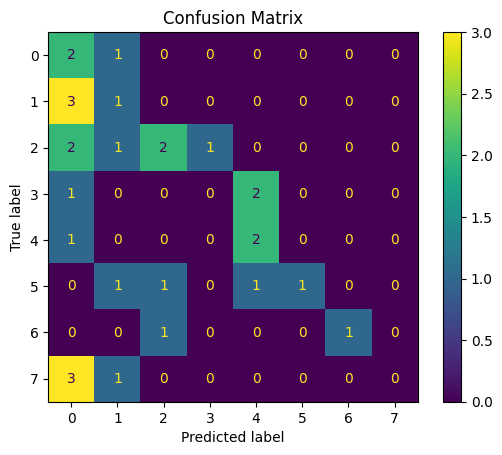

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

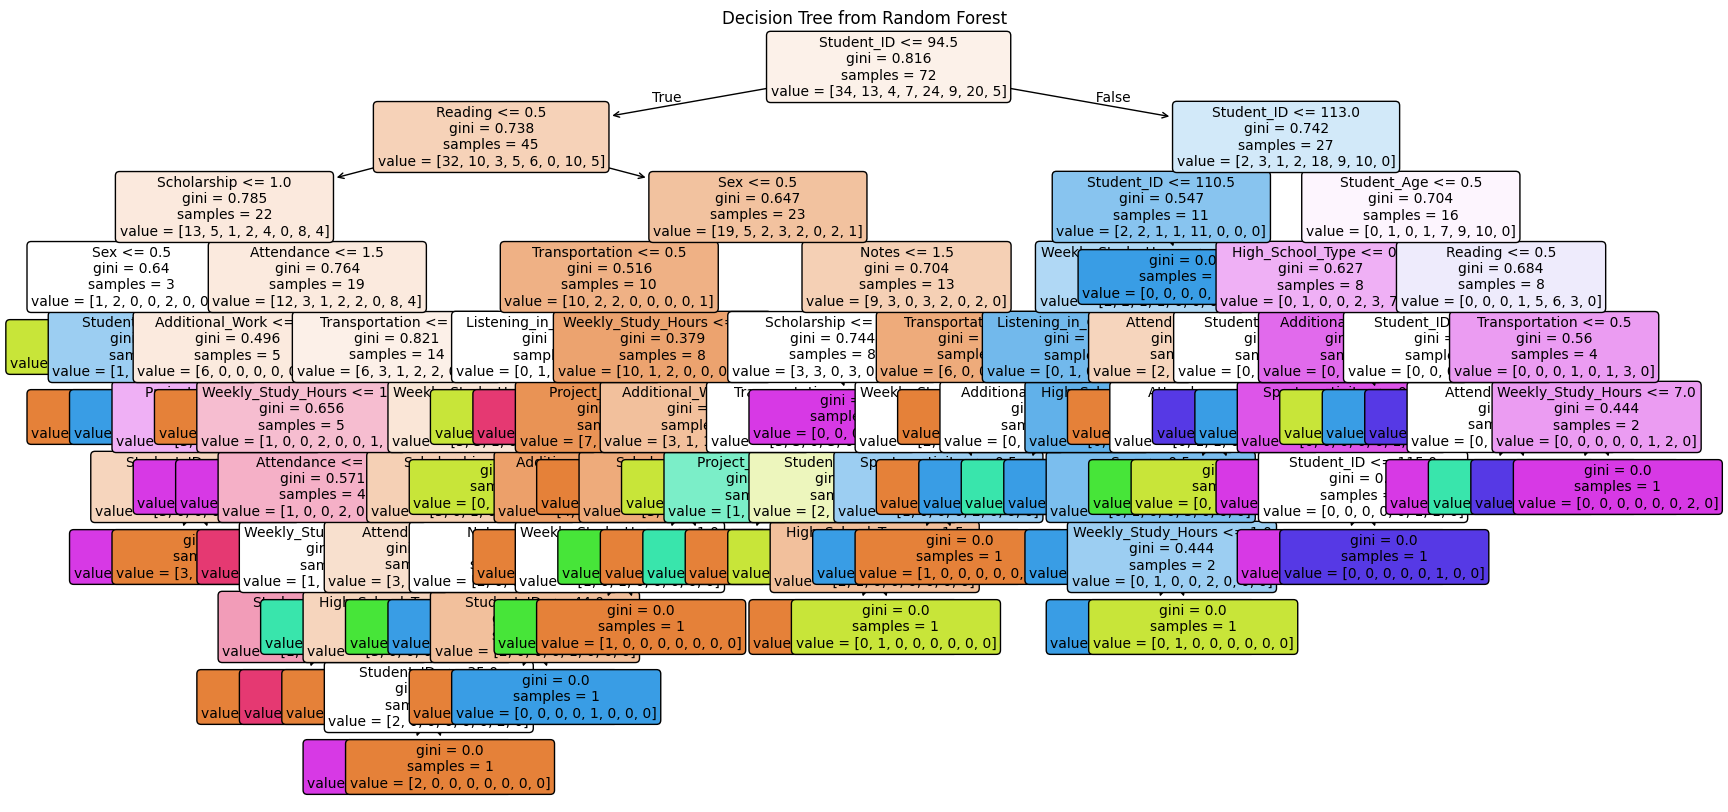

In [34]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = classifier.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=X.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()